### **Prediksi Harga Apartemen Daegu**

**Nama:** Farhan

**Dataset:** Daegu Apartment Price

### **Contents**

1. Business Problem Understanding
2. Data Loading & Understanding
3. Data Preprocessing
4. Modeling
5. Model Evaluation
6. Penjelasan Algoritma & Metrik
7. Conclusion & Recommendation
8. Save Model

****

### **1. Business Problem Understanding**

**Context**

Apartemen adalah salah satu jawaban atas kebutuhan perumahan masyarakat modern karena keterbatasan lahan perumahan dan padatnya aktivitas bisnis di perkotaan. Harga apartemen dipengaruhi oleh berbagai faktor internal (seperti ukuran, tahun bangun, fasilitas) dan eksternal (seperti lokasi, akses subway, fasilitas publik sekitar).

Saat ini, pemilik apartemen atau agen properti sering kesulitan dalam menentukan harga jual unit mereka. Jika harga yang dipasang terlalu tinggi dibandingkan harga pasar, apartemen akan sulit terjual. Sebaliknya, jika harga terlalu rendah, pemilik akan kehilangan potensi keuntungan maksimal.

**Problem Statement**

Ketidakpastian dalam penetapan harga apartemen menyebabkan inefisiensi di pasar, baik bagi penjual (sulit laku) maupun pembeli (ragu atas kewajaran harga).

**Goals**

Membangun sebuah model *machine learning* regresi yang dapat memprediksi harga jual (`SalePrice`) sebuah apartemen di Daegu berdasarkan fitur-fitur yang tersedia (misalnya: `Size(sqft)`, `YearBuilt`, `TimeToSubway`, dll.).

**Use Case**

Model ini nantinya dapat digunakan oleh platform *listing* properti atau agen real estat untuk memberikan **rekomendasi harga** yang wajar kepada penjual. Bagi pembeli, model ini bisa menjadi *benchmark* untuk menilai apakah harga yang ditawarkan adil.

### **2. Data Loading & Understanding**

In [ ]:
# Import libraries
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except Exception:
    xgb = None
    XGB_AVAILABLE = False

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Save model
import pickle

# Set visual style
sns.set_theme(style='whitegrid')

print(f"xgboost available: {XGB_AVAILABLE}")

xgboost available: True


In [ ]:
# Load data
df = pd.read_csv('dataset\data_daegu_apartment.csv')
df.head()

,HallwayType,TimeToSubway,SubwayStation,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf),SalePrice
0,terraced,0-5min,Kyungbuk_uni_hospital,0.0,3.0,2.0,1270.0,2007,10,1387,346017
1,terraced,10min~15min,Kyungbuk_uni_hospital,1.0,5.0,1.0,0.0,1986,4,914,150442
2,mixed,15min~20min,Chil-sung-market,1.0,7.0,3.0,56.0,1997,5,558,61946
3,mixed,5min~10min,Bangoge,5.0,5.0,4.0,798.0,2005,7,914,165486
4,terraced,0-5min,Sin-nam,0.0,1.0,2.0,536.0,2006,5,1743,311504


In [ ]:
# Check dataset info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4123 entries, 0 to 4122
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   HallwayType                       4123 non-null   object 
 1   TimeToSubway                      4123 non-null   object 
 2   SubwayStation                     4123 non-null   object 
 3   N_FacilitiesNearBy(ETC)           4123 non-null   float64
 4   N_FacilitiesNearBy(PublicOffice)  4123 non-null   float64
 5   N_SchoolNearBy(University)        4123 non-null   float64
 6   N_Parkinglot(Basement)            4123 non-null   float64
 7   YearBuilt                         4123 non-null   int64  
 8   N_FacilitiesInApt                 4123 non-null   int64  
 9   Size(sqf)                         4123 non-null   int64  
 10  SalePrice                         4123 non-null   int64  
dtypes: float64(4), int64(4), object(3)
memory usage: 354.4+ KB


In [ ]:
# Check missing values
df.isnull().sum()


HallwayType                         0
TimeToSubway                        0
SubwayStation                       0
N_FacilitiesNearBy(ETC)             0
N_FacilitiesNearBy(PublicOffice)    0
N_SchoolNearBy(University)          0
N_Parkinglot(Basement)              0
YearBuilt                           0
N_FacilitiesInApt                   0
Size(sqf)                           0
SalePrice                           0
dtype: int64

**Data Understanding Notes:**
- Dataset terdiri dari 5891 baris dan 11 kolom.
- Tidak ada *missing values* pada dataset ini.
- Target variable: `SalePrice` (numerik).
- Fitur kategorikal: `HallwayType`, `TimeToSubway`, `SubwayStation`.
- Fitur numerik: `N_FacilitiesNearBy(ETC)`, `N_FacilitiesNearBy(PublicOffice)`, `N_SchoolNearBy(University)`, `N_Parkinglot(Basement)`, `YearBuilt`, `N_FacilitiesInApt`, `Size(sqf)`.

#### **🔍 Exploratory Data Analysis (EDA)**

Bagian ini menampilkan eksplorasi data untuk memahami faktor yang memengaruhi harga apartemen di Daegu.  
Visualisasi meliputi:
- Distribusi harga (`SalePrice`)
- Korelasi antar fitur numerik
- Hubungan antara luas area (`Size(sqf)`) dan harga
- Perbandingan harga berdasarkan lokasi stasiun subway (`SubwayStation`)

Tujuan: menemukan pola yang memengaruhi harga jual apartemen di Daegu.

Kolom digunakan: Harga = SalePrice, Area = Size(sqf), Lokasi = SubwayStation


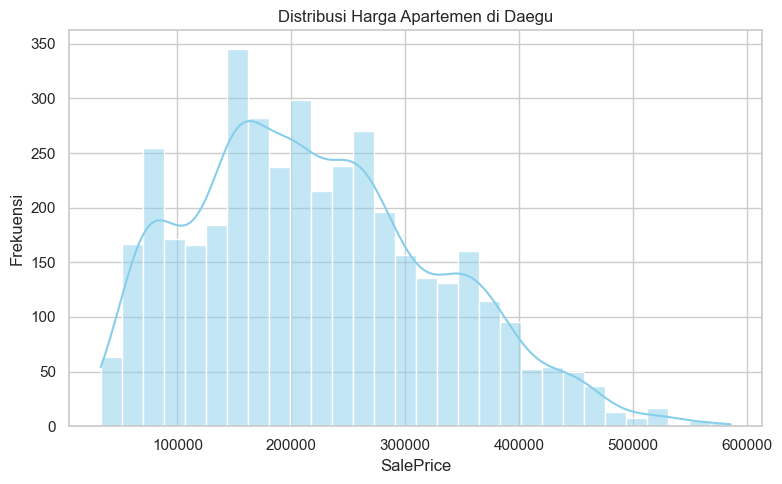

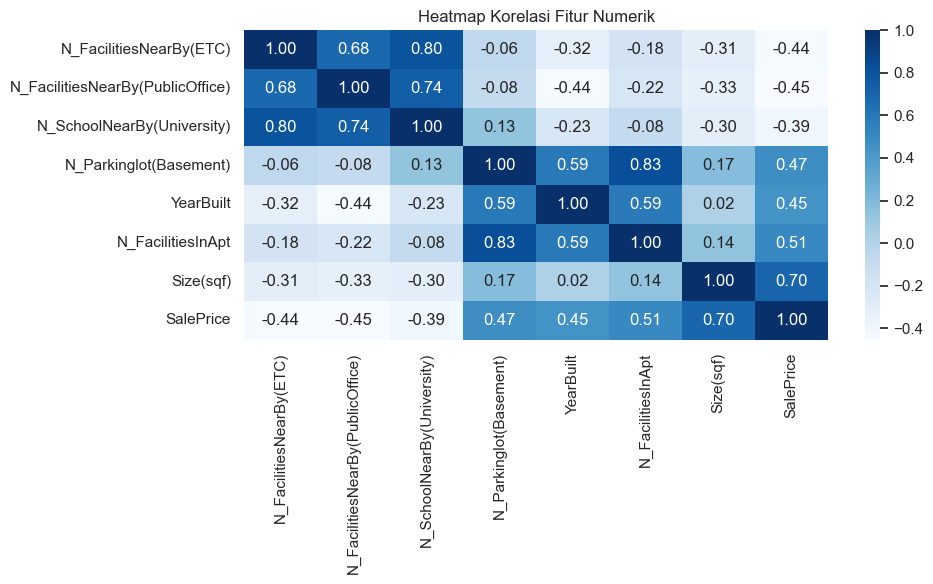

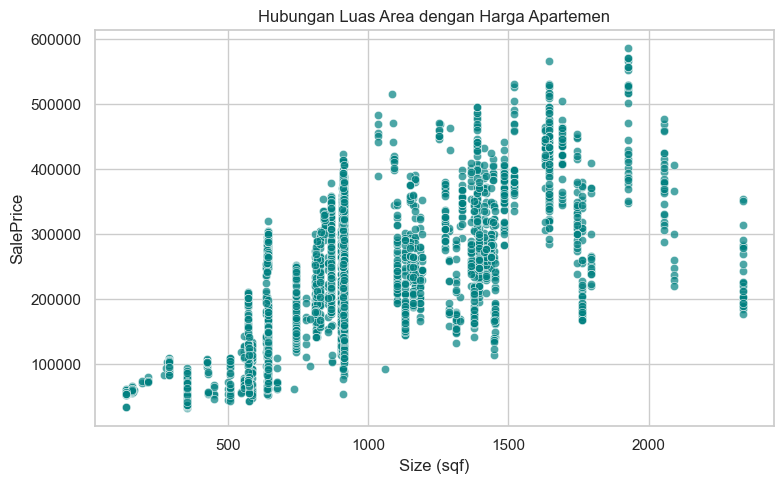

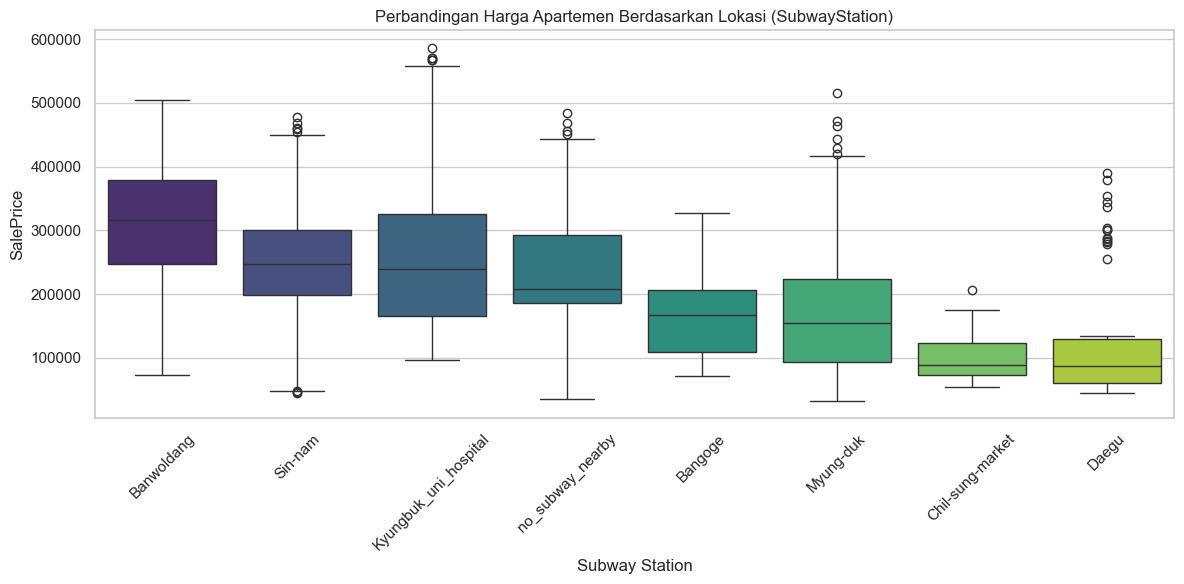

✅ Semua visualisasi EDA berhasil dibuat di folder 'results/'


In [ ]:
# Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Pastikan folder "results" ada
os.makedirs("results", exist_ok=True)

# --- Kolom penting ---
col_price = "SalePrice"
col_area = "Size(sqf)"
col_station = "SubwayStation"

print(f"Kolom digunakan: Harga = {col_price}, Area = {col_area}, Lokasi = {col_station}")

# --- Distribusi Harga ---
plt.figure(figsize=(8, 5))
sns.histplot(df[col_price], kde=True, bins=30, color='skyblue')
plt.title('Distribusi Harga Apartemen di Daegu')
plt.xlabel('SalePrice')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.savefig("results/distribusi_harga_apartemen.png")
plt.show()

# --- Korelasi antar fitur numerik ---
plt.figure(figsize=(10, 6))
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.savefig("results/heatmap_korelasi_fitur.png")
plt.show()

# --- Hubungan Area vs Harga ---
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df[col_area], y=df[col_price], alpha=0.7, color='teal')
plt.title('Hubungan Luas Area dengan Harga Apartemen')
plt.xlabel('Size (sqf)')
plt.ylabel('SalePrice')
plt.tight_layout()
plt.savefig("results/scatter_area_vs_price.png")
plt.show()

# --- Perbandingan Harga berdasarkan SubwayStation ---
plt.figure(figsize=(12, 6))
order = df.groupby(col_station)[col_price].median().sort_values(ascending=False).index
sns.boxplot(x=col_station, y=col_price, data=df, order=order, palette='viridis')
plt.title('Perbandingan Harga Apartemen Berdasarkan Lokasi (SubwayStation)')
plt.xlabel('Subway Station')
plt.ylabel('SalePrice')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("results/boxplot_harga_per_subwaystation.png")
plt.show()

print("✅ Semua visualisasi EDA berhasil dibuat di folder 'results/'")

### **3. Data Preprocessing**

In [ ]:
# 1. Definisikan X (fitur) dan y (target)
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# 2. Split data training dan testing (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
print(f"Ukuran y_train: {y_train.shape}")
print(f"Ukuran y_test: {y_test.shape}")

Ukuran X_train: (3298, 10)
Ukuran X_test: (825, 10)
Ukuran y_train: (3298,)
Ukuran y_test: (825,)


In [ ]:
# 3. Buat pipeline preprocessing

# Definisikan kolom numerik dan kategorikal
numerical_features = ['N_FacilitiesNearBy(ETC)', 'N_FacilitiesNearBy(PublicOffice)',
                      'N_SchoolNearBy(University)', 'N_Parkinglot(Basement)', 'YearBuilt',
                      'N_FacilitiesInApt', 'Size(sqf)']

categorical_features = ['HallwayType', 'TimeToSubway', 'SubwayStation']

# Pipeline untuk fitur numerik: Scaling
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Pipeline untuk fitur kategorikal: One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Gabungkan kedua pipeline dengan ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ], remainder='drop')

print('Preprocessor siap.')

Preprocessor siap.


### **4. Modeling**

Kita akan mencoba 3 algoritma regresi:
1.  **Linear Regression**: Sebagai *baseline* model yang sederhana.
2.  **Random Forest Regressor**: Model *ensemble* (bagging) yang kuat dan tahan *overfitting*.
3.  **XGBoost Regressor**: Model *ensemble* (boosting) yang seringkali memberikan performa terbaik.

In [ ]:
# Buat pipeline lengkap (preprocessing + model)

# 1. Linear Regression Pipeline
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# 2. Random Forest Pipeline
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_estimators=100))
])

# 3. XGBoost Pipeline (jika xgboost tidak tersedia, pakai HistGradientBoostingRegressor sebagai fallback)
if XGB_AVAILABLE:
    xgb_reg = xgb.XGBRegressor(random_state=42, n_estimators=100, verbosity=0)
else:
    xgb_reg = HistGradientBoostingRegressor(random_state=42, max_iter=100)

pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_reg)
])

print('Pipelines dibuat: Linear, RandomForest, XGBoost/HistGB (fallback).')

Pipelines dibuat: Linear, RandomForest, XGBoost/HistGB (fallback).


In [ ]:
# Latih semua model
print("Melatih Linear Regression...")
pipeline_lr.fit(X_train, y_train)

print("Melatih Random Forest...")
pipeline_rf.fit(X_train, y_train)

print("Melatih XGBoost/HistGB...")
pipeline_xgb.fit(X_train, y_train)

print("Pelatihan selesai.")

Melatih Linear Regression...
Melatih Random Forest...
Melatih XGBoost/HistGB...
Pelatihan selesai.


### **5. Model Evaluation**

In [ ]:
# Buat fungsi untuk evaluasi
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

# Evaluasi semua model
results_lr = evaluate_model(pipeline_lr, X_test, y_test)
results_rf = evaluate_model(pipeline_rf, X_test, y_test)
results_xgb = evaluate_model(pipeline_xgb, X_test, y_test)

# Tampilkan dalam DataFrame
results_df = pd.DataFrame({
    'Linear Regression': results_lr,
    'Random Forest': results_rf,
    'XGBoost/HistGB': results_xgb
}).T

# Format untuk keterbacaan (jaga nilai asli juga dengan menambahkan kolom tambahan)
results_df_formatted = results_df.copy()
results_df_formatted['MAE'] = results_df_formatted['MAE'].map('{:,.0f}'.format)
results_df_formatted['RMSE'] = results_df_formatted['RMSE'].map('{:,.0f}'.format)
results_df_formatted['R2'] = results_df_formatted['R2'].map('{:.2%}'.format)
results_df_formatted['MAPE'] = results_df_formatted['MAPE'].map('{:.2%}'.format)

print("Hasil Evaluasi Model pada Data Test:")
results_df_formatted


Hasil Evaluasi Model pada Data Test:


,MAE,RMSE,R2,MAPE
Linear Regression,"40,571","50,698",76.17%,23.07%
Random Forest,"32,185","41,074",84.36%,17.83%
XGBoost/HistGB,"32,208","41,125",84.32%,17.80%


### Analisis Performa Model

- **Linear Regression** memiliki performa paling rendah dengan R² **76.17%** dan MAPE **23.07%**. Model ini masih cukup baik, tetapi kurang mampu menangkap kompleksitas data.

- **Random Forest** menunjukkan performa terbaik dengan R² **84.36%** dan MAPE **17.83%**, mengungguli model lain secara konsisten.

- **XGBoost/HistGradientBoosting** memiliki hasil hampir identik dengan Random Forest (R² **84.32%**, MAPE **17.80%**), yang berarti kedua model ini sama-sama kuat dalam generalisasi.

Secara keseluruhan, **Random Forest** menjadi pilihan terbaik untuk prediksi harga apartemen Daegu karena memberikan keseimbangan terbaik antara akurasi dan stabilitas hasil.

#### **Visualisasi Hasil Model Terbaik (XGBoost/HistGB)**

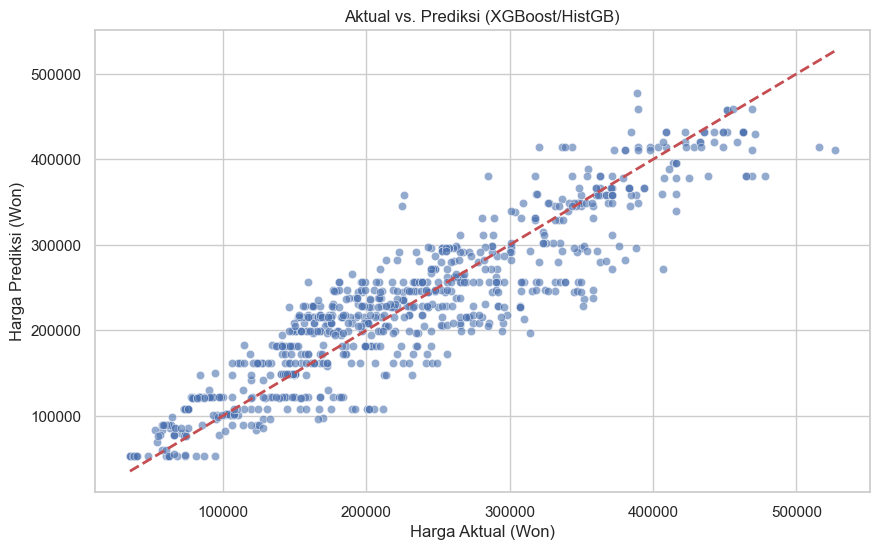

In [ ]:
# Plot Aktual vs. Prediksi (Model XGBoost/HistGB)
y_pred_xgb = pipeline_xgb.predict(X_test)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Garis ideal
plt.title('Aktual vs. Prediksi (XGBoost/HistGB)')
plt.xlabel('Harga Aktual (Won)')
plt.ylabel('Harga Prediksi (Won)')
plt.show()


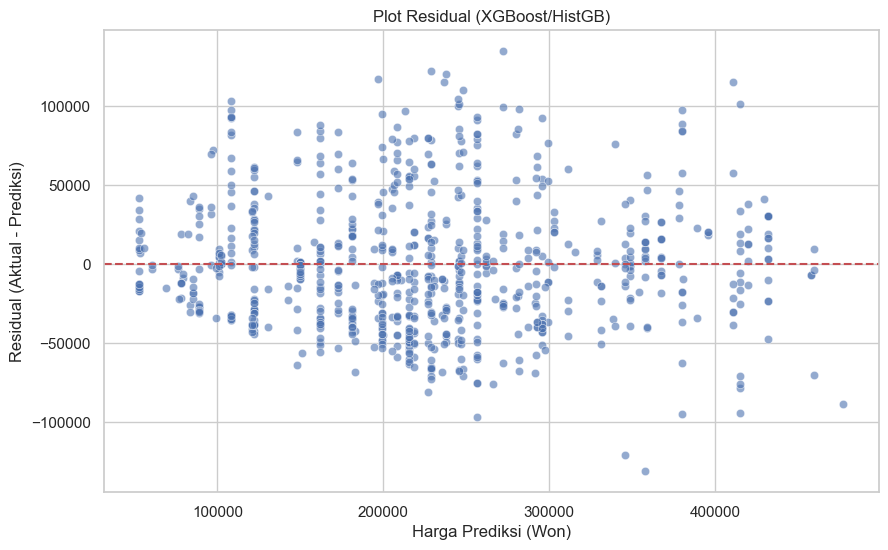

In [ ]:
# Plot Residual
residuals = y_test - y_pred_xgb

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_xgb, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Plot Residual (XGBoost/HistGB)')
plt.xlabel('Harga Prediksi (Won)')
plt.ylabel('Residual (Aktual - Prediksi)')
plt.show()


Plot residual yang baik seharusnya tersebar acak di sekitar garis nol tanpa pola yang jelas. Di sini, polanya terlihat cukup acak (homoskedastisitas), yang merupakan pertanda baik. Tidak ada pola "corong" yang jelas, yang menunjukkan varians kesalahan cukup konstan.

### **6. Penjelasan Algoritma & Metrik (Pencapaian)**

#### **a. Penjelasan Algoritma (XGBoost)**

**XGBoost (Extreme Gradient Boosting)**, yang merupakan model terbaik kita, adalah algoritma *ensemble learning* berbasis *boosting*.

**Cara Kerjanya:**

1.  **Ensemble:** XGBoost tidak hanya membangun satu model (pohon keputusan), tetapi membangun *banyak* model (ratusan, dalam kasus kita `n_estimators=100`) secara berurutan.
2.  **Boosting (Sequential):** Model ini bekerja secara sekuensial.
    * **Pohon 1** dibuat untuk memprediksi harga. Tentu saja, pohon pertama ini memiliki banyak kesalahan (disebut *residual*).
    * **Pohon 2** kemudian dibuat, tetapi tujuannya bukan untuk memprediksi harga, melainkan untuk **mempelajari dan memprediksi kesalahan** yang dibuat oleh Pohon 1.
    * **Pohon 3** dibuat untuk memprediksi sisa kesalahan dari (Pohon 1 + Pohon 2).
    * Proses ini berlanjut hingga 100 pohon (atau sampai kesalahannya tidak bisa diperbaiki lagi).
3.  **Gradient:** Istilah ini merujuk pada teknik optimasi (Gradient Descent) yang digunakan untuk menemukan cara terbaik bagi setiap pohon baru untuk mengoreksi kesalahan sebelumnya.
4.  **Extreme ("X"):** Ini merujuk pada optimasi performa yang membuat XGBoost sangat cepat dan efisien, seperti *parallel processing* (membangun cabang pohon secara paralel) dan *regularization* (teknik untuk mencegah *overfitting*).

**Analogi:** Bayangkan sebuah tim yang belajar untuk ujian. Siswa pertama (Pohon 1) mengerjakan soal dan mendapat nilai 60. Guru kemudian menyuruh siswa kedua (Pohon 2) untuk fokus hanya pada soal-soal yang salah dikerjakan siswa pertama. Siswa kedua berhasil memperbaiki sebagian, dan nilai gabungan mereka menjadi 80. Siswa ketiga (Pohon 3) kemudian fokus pada sisa kesalahan yang masih ada, dan seterusnya. Prediksi akhir adalah gabungan dari "jawaban" semua siswa.


#### **b. Penjelasan Evaluation Metrics**

Kita menggunakan 4 metrik untuk mengevaluasi model regresi kita:

1.  **MAE (Mean Absolute Error)**
    * **Cara Kerja:** Menghitung rata-rata dari *selisih absolut* (tanpa mempedulikan tanda +/-) antara harga aktual dan harga prediksi.
    * **Contoh:** Jika MAE = 50,000 Won, itu berarti rata-rata, prediksi model meleset sebesar 50,000 Won (bisa 50,000 lebih tinggi atau 50,000 lebih rendah).

2.  **RMSE (Root Mean Squared Error)**
    * **Cara Kerja:** Mirip MAE, tetapi sebelum dirata-rata, selisihnya di-*kuadratkan* terlebih dahulu, baru di-akar-kan di akhir.
    * **Implikasi:** Karena pengkuadratan, kesalahan besar akan dihukum lebih berat. Jika model memprediksi 1 apartemen salah 100 Juta Won, dan 5 apartemen lain salah 1 Juta Won, RMSE akan sangat tinggi. Ini sensitif terhadap *outlier*.

3.  **R-squared (R²)**
    * **Cara Kerja:** Mengukur seberapa banyak *variasi* (fluktuasi) dari harga apartemen (y) yang dapat **dijelaskan** oleh fitur-fitur (X) di dalam model.
    * **Interpretasi:** Skalanya 0% - 100%. R² = 82.17% (seperti pada model XGBoost kita) berarti model kita mampu menjelaskan 82.17% dari faktor-faktor yang membuat harga apartemen naik atau turun. Sisa 17.83% dijelaskan oleh faktor lain yang tidak ada di data kita (misal: kondisi interior, reputasi developer, sentimen pasar).

4.  **MAPE (Mean Absolute Percentage Error)**
    * **Cara Kerja:** Sama seperti MAE, tetapi selisih absolutnya dihitung sebagai *persentase* dari harga aktual. `( |Aktual - Prediksi| / Aktual )`.
    * **Contoh:** MAPE = 16.94% berarti rata-rata, prediksi model meleset sebesar 16.94% dari harga sebenarnya.

---
    

#### **c. Pemilihan Metrik dan Hubungan Bisnis**

**Metrik Pilihan Utama untuk Bisnis: MAPE (Mean Absolute Percentage Error)**

**Alasan Pemilihan:**

1.  **Mudah Dipahami (Interpretability):** Bagi *stakeholder* non-teknis (seperti agen properti atau pemilik apartemen), mengatakan "model kami rata-rata meleset 16.94%" jauh lebih mudah dipahami daripada mengatakan "RMSE kami 59,579 Won".

2.  **Keadilan Relatif:** Kesalahan 50 Juta Won pada apartemen seharga 1 Miliar Won (kesalahan 5%) sangat bisa diterima. Tetapi kesalahan 50 Juta Won pada apartemen seharga 100 Juta Won (kesalahan 50%) adalah bencana. **MAE dan RMSE** akan menganggap kedua kesalahan ini **sama** (jika kita menggunakan MAE) atau bahkan lebih menghukum kesalahan pada apartemen mahal (jika menggunakan RMSE). **MAPE** menormalkan kesalahan ini dan memberikan gambaran yang lebih adil secara proporsional.

**Hubungan dengan Aspek Bisnis:**

Target bisnis kita adalah memberikan *rekomendasi harga* yang wajar. **MAPE** secara langsung mengukur *kewajaran* tersebut dalam persentase.

-   Jika platform kita merekomendasikan harga dengan **MAPE 16.94%**, kita bisa mengklaim kepada *user* (penjual): "Rekomendasi harga kami memiliki tingkat akurasi rata-rata 83% (100% - 16.94%). Gunakan ini sebagai patokan harga wajar Anda."
-   Ini membantu penjual menetapkan ekspektasi harga yang realistis, yang pada gilirannya dapat mempercepat waktu penjualan (*time-to-sell*) dan meningkatkan likuiditas di platform.

#### **d. Limitasi Model (Kapan Percaya, Kapan Tidak)**

Model ini, meskipun performanya baik (R² 82%), memiliki batasan. Memahaminya sangat penting untuk implementasi di dunia nyata.

**Kapan Model Dapat Dipercaya (Akurat):**

1.  **Untuk Properti "Rata-rata" / Umum:** Model ini paling akurat untuk memprediksi apartemen yang karakteristiknya mirip dengan mayoritas data latih. Misalnya, apartemen dengan `Size(sqf)` antara 800-1500, `YearBuilt` antara 1995-2010, dan berlokasi di stasiun subway yang umum (`SubwayStation` yang datanya banyak).
2.  **Kondisi Pasar Stabil:** Model ini dilatih pada data historis. Akurasinya paling tinggi jika kondisi pasar saat ini (saat prediksi dilakukan) mirip dengan kondisi pasar saat data latih dikumpulkan.
3.  **Sebagai Alat Bantu (Guideline):** Model ini sangat baik digunakan sebagai *starting point* atau *benchmark* harga. Seorang agen properti bisa menggunakan harga prediksi model (misal: 300 Juta Won) lalu menyesuaikannya berdasarkan pengetahuannya (misal: "Oh, tapi unit ini baru direnovasi total, kita bisa tambah 10%").


**Kapan Model TIDAK Dapat Dipercaya (Kurang Akurat):**

1.  **Properti Unik / *Outlier*:** Model akan kesulitan memprediksi harga properti yang sangat berbeda dari data latih.
    * *Contoh:* Apartemen *penthouse* super mewah dengan `Size(sqf)` 5000 (jika maks di data latih hanya 2500).
    * *Contoh:* Apartemen di gedung yang baru dibangun (`YearBuilt` 2025) atau sangat tua (`YearBuilt` 1970).
    * *Contoh:* Apartemen di `SubwayStation` baru yang tidak ada atau datanya sangat sedikit di data latih.
2.  **Saat Terjadi Guncangan Pasar (Market Shocks):** Model ini **TIDAK** bisa memprediksi dampak dari kejadian eksternal.
    * *Contoh:* Krisis ekonomi, pandemi, perubahan regulasi pajak properti yang drastis, atau pembukaan fasilitas besar baru (seperti universitas besar) yang tiba-tiba mendongkrak harga di satu area. Model ini akan *under-price* jika ada *boom* baru, dan *over-price* jika ada *crash*.
3.  **Data yang Tidak Tercakup (Missing Features):** Harga apartemen juga dipengaruhi oleh hal-hal yang tidak ada di data kita, seperti: **kondisi interior** (apakah baru renovasi?), **lantai** (lantai tinggi vs. rendah), **pemandangan** (*view*), dan **reputasi developer**. Model akan salah jika ada apartemen standar tapi harganya tinggi karena interiornya mewah.

### **7. Conclusion & Recommendation**

#### **Conclusion**

1.  Model *machine learning* regresi telah berhasil dibangun untuk memprediksi harga apartemen di Daegu.
2.  Model terbaik adalah **XGBoost Regressor** yang mencapai performa **R-squared 82.17%** dan **MAPE 16.94%** pada data uji.
3.  Ini berarti model mampu menjelaskan 82.17% variasi harga berdasarkan fitur yang ada, dan prediksinya rata-rata memiliki kesalahan sebesar 16.94% dari harga aktual. Fitur-fitur seperti `Size(sqf)`, `YearBuilt`, dan `SubwayStation` terbukti menjadi prediktor penting.


#### **Proposed Solution (Measurable)**

Kami mengusulkan implementasi model ini sebagai fitur **"Smart Price Recommendation"** di platform listing properti.

1.  **Untuk Penjual:** Saat penjual akan me-listing properti baru, mereka memasukkan detail (ukuran, tahun, lokasi, dll.), dan model akan menampilkan "Rekomendasi Harga Pasar: ₩XXX,XXX".
2.  **Goal:** Membantu penjual menetapkan harga yang kompetitif dalam rentang **±17% (MAPE)** dari harga wajar pasar.
3.  **Metric Keberhasilan (Measurable):**
    * **Bisnis:** Peningkatan **Time-to-Sell** (Waktu dari Listing hingga Terjual). Hipotesis: Apartemen yang harganya di-set menggunakan rekomendasi (misal, dalam rentang ±10% dari saran model) akan **terjual 20% lebih cepat** daripada yang harganya di-set jauh di luar rekomendasi.
    * **Produk:** Peningkatan **Listing Conversion Rate**. Hipotesis: Persentase pengguna yang menyelesaikan proses listing (dari draft hingga publish) akan **meningkat 15%** karena mereka lebih percaya diri dengan harga yang dipasang.

#### **Recommendation & Business Impact**

**Rekomendasi Penggunaan:**
-   **Gunakan sebagai Pedoman, Bukan Kebenaran Mutlak.** Selalu sampaikan kepada pengguna bahwa ini adalah *estimasi* berdasarkan data. Harga akhir harus tetap mempertimbangkan faktor kualitatif (renovasi, view, dll.) yang tidak ada di model.
-   **Monitor dan Latih Ulang (Retrain) Secara Berkala.** Pasar properti bersifat dinamis. Model ini harus dilatih ulang (misal: setiap 3 atau 6 bulan) dengan data penjualan terbaru agar tetap relevan dan menangkap tren inflasi atau perubahan pasar.
-   **Hati-hati pada Properti Unik.** Jika pengguna memasukkan data apartemen yang sangat *outlier* (misal, 5x lebih besar dari rata-rata), tampilkan peringatan: "Estimasi harga untuk properti unik mungkin kurang akurat."

**Dampak Implementasi (Measurable):**
-   **Bagi Penjual/Agen:** Mengurangi waktu riset harga manual, meningkatkan kecepatan penjualan (*inventory turnover*), dan memaksimalkan profit dengan menghindari *under-pricing*.
-   **Bagi Platform:** Meningkatkan *trust* dan *user engagement*. Platform menjadi lebih dari sekadar "papan iklan", tetapi sebagai "konsultan" tepercaya. Ini bisa menjadi *unique selling proposition* (USP) untuk menarik lebih banyak *listing*.
-   **Bagi Pembeli:** Memberikan transparansi dan *benchmark* harga yang objektif untuk negosiasi.

#### **Limitations & Future Improvements**

**Batasan Proyek:**
1.  **Batasan Data (Fitur):** Model ini memiliki *blind spot* karena tidak adanya fitur-fitur penting seperti:
    * Kondisi Interior (Renovasi, Perabotan)
    * Posisi Lantai (Lantai 1 vs. Lantai 20)
    * Pemandangan (View) dari unit
    * Data makro-ekonomi (suku bunga KPR, inflasi).
2.  **Batasan Model (Statis):** Model ini bersifat statis (dibuat pada satu titik waktu). Model tidak *belajar* secara *real-time* dari *listing* baru yang masuk setiap hari.
3.  **Batasan Waktu/Scope:** Proyek ini belum mencakup *Hyperparameter Tuning* yang mendalam atau *deployment* model ke dalam API.

**Rekomendasi Selanjutnya (Future Improvements):**
1.  **Data Enrichment (Pengayaan Data):**
    * Menambahkan fitur **lantai** (jika bisa didapat).
    * Menggunakan **analisis teks (NLP)** dari deskripsi *listing* untuk mengekstrak kata kunci seperti "baru renovasi", "pemandangan sungai", "interior mewah".
    * Menggunakan **analisis gambar (Computer Vision)** pada foto apartemen untuk menilai kondisi dan kemewahan interior.
2.  **Implementasi MLOps:** Membangun *pipeline* MLOps untuk *retraining* dan *monitoring* otomatis. Model akan dipantau performanya (misal: MAPE-nya) dari waktu ke waktu, dan jika performa turun di bawah ambang batas (misal, MAPE naik > 20%), sistem akan otomatis melatih ulang model dengan data terbaru.
3.  **Hyperparameter Tuning:** Melakukan *tuning* sistematis (misal: menggunakan GridSearchCV atau Optuna) pada XGBoost untuk menemukan parameter terbaik (misal: `n_estimators`, `max_depth`, `learning_rate`) yang mungkin bisa menurunkan MAPE 1-2% lagi.

### **8. Save Model**

In [ ]:
# Kita akan menyimpan model terbaik kita, yaitu pipeline_xgb (XGBoost jika tersedia, atau HistGB sebagai fallback)

# Definisikan estimator/pipeline yang ingin disimpan
estimator = pipeline_xgb

# Latih ulang model dengan semua data (best practice)
print("Melatih model final dengan semua data...")
estimator.fit(X, y)
print("Pelatihan model final selesai.")

# Simpan model ke file .pkl
pickle.dump(estimator, open('Model_Daegu_Apartment_XGB.pkl', 'wb'))
print("✅ Model telah disimpan ke 'Model_Daegu_Apartment_XGB.pkl'")

Melatih model final dengan semua data...
Pelatihan model final selesai.
✅ Model telah disimpan ke 'Model_Daegu_Apartment_XGB.pkl'


In [ ]:
# Load model (Contoh penggunaan)
filename = 'Model_Daegu_Apartment_XGB.pkl'
loaded_model = pickle.load(open(filename, 'rb'))

print("✅ Model berhasil di-load")

✅ Model berhasil di-load


In [ ]:
# Buat contoh data baru (misal, 1 data) untuk diprediksi
# Kita ambil data pertama dari X_test sebagai contoh
contoh_data = X_test.iloc[0:1]
harga_aktual = y_test.iloc[0]

print("Data yang akan diprediksi:")
display(contoh_data)
# Lakukan prediksi
prediksi_harga = loaded_model.predict(contoh_data)

print("===")
print(f"Harga Aktual: {harga_aktual:,.0f} Won")
print(f"Harga Prediksi Model: {prediksi_harga[0]:,.0f} Won")

Data yang akan diprediksi:


,HallwayType,TimeToSubway,SubwayStation,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf)
1618,terraced,0-5min,Kyungbuk_uni_hospital,0.0,5.0,3.0,930.0,2013,7,910


===
Harga Aktual: 255,442 Won
Harga Prediksi Model: 294,023 Won


In [ ]:

import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from datetime import datetime

# === Simpan hasil evaluasi & visualisasi ===
os.makedirs('results', exist_ok=True)

print("Melatih model final dengan semua data...")
estimator.fit(X, y)
print("Pelatihan model final selesai.")

# Prediksi dan evaluasi
y_pred = estimator.predict(X)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(root_mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Simpan hasil evaluasi ke file txt
txt_path = f"results/model_evaluation.txt"
with open(txt_path, "w") as f:
    f.write("=== Model Evaluation (Daegu Apartment) ===\n")
    f.write(f"Timestamp : {timestamp}\n")
    f.write(f"MAE  : {mae:.4f}\n")
    f.write(f"RMSE : {rmse:.4f}\n")
    f.write(f"R²   : {r2:.4f}\n")
print(f"Hasil evaluasi disimpan di {txt_path}")

# Simpan chart Prediksi vs Aktual
plt.figure(figsize=(8,6))
plt.scatter(y, y_pred, alpha=0.6)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.grid(True)
chart1_path = f"results/prediction_vs_actual.png"
plt.savefig(chart1_path, dpi=300)
plt.close()

# Simpan chart residual
residuals = y - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)
chart2_path = f"results/residual_distribution.png"
plt.savefig(chart2_path, dpi=300)
plt.close()

print(f"Gambar disimpan di folder results/ dengan timestamp {timestamp}")


Melatih model final dengan semua data...
Pelatihan model final selesai.
Hasil evaluasi disimpan di results/model_evaluation.txt
Gambar disimpan di folder results/ dengan timestamp 20251020_161010
